In [20]:
import numpy as np

# ----------------------------
# Utilities
# ----------------------------
def sigmoid(z):
    z = np.clip(z, -35, 35)
    return 1.0 / (1.0 + np.exp(-z))

def fisher_info_2pl(a, b, theta):
    p = sigmoid(a * (theta - b))
    return (a**2) * p * (1 - p)

def simulate_response(a, b, theta_true, rng):
    p = sigmoid(a * (theta_true - b))
    return 1 if rng.random() < p else 0


# ----------------------------
# EAP (Normal prior)
# ----------------------------
def eap_estimate(u, a, b, mu0=0.0, sigma0=1.0,
                 quad_theta=None, quad_w=None):

    if len(u) == 0:
        return mu0

    if quad_theta is None:
        quad_theta = np.linspace(-4, 4, 161)
        quad_w = np.ones_like(quad_theta)
        quad_w[0] = quad_w[-1] = 0.5
        quad_w *= (quad_theta[1] - quad_theta[0])

    log_prior = -0.5 * ((quad_theta - mu0) / sigma0) ** 2

    logL = np.zeros_like(quad_theta)
    for ut, at, bt in zip(u, a, b):
        p = sigmoid(at * (quad_theta - bt))
        p = np.clip(p, 1e-12, 1 - 1e-12)
        logL += ut * np.log(p) + (1 - ut) * np.log(1 - p)

    log_post = logL + log_prior
    m = np.max(log_post)
    post = np.exp(log_post - m) * quad_w

    denom = np.sum(post)
    if denom <= 0:
        return mu0

    return np.sum(quad_theta * post) / denom


# ----------------------------
# Robust MLE with bounds
# ----------------------------
def mle_estimate(u, a, b, theta_init=0.0,
                 bounds=(-4, 4),
                 max_iter=30,
                 tol=1e-4):

    if len(u) == 0:
        return theta_init

    lo, hi = bounds

    # Extreme patterns
    if np.sum(u) == 0:
        return lo
    if np.sum(u) == len(u):
        return hi

    theta = theta_init

    for _ in range(max_iter):
        p = sigmoid(a * (theta - b))
        p = np.clip(p, 1e-10, 1 - 1e-10)

        score = np.sum(a * (u - p))
        info = np.sum((a**2) * p * (1 - p))

        if info < 1e-8:
            break

        step = score / info
        step = np.clip(step, -0.7, 0.7)

        theta_new = theta + step
        theta_new = np.clip(theta_new, lo, hi)

        if abs(theta_new - theta) < tol:
            theta = theta_new
            break

        theta = theta_new

    return float(theta)


# ----------------------------
# EKF update
# ----------------------------
def ekf_update(theta_pred, P_pred, u, a, b):
    p = sigmoid(a * (theta_pred - b))
    p = np.clip(p, 1e-10, 1 - 1e-10)

    H = a * p * (1 - p)
    R = p * (1 - p)

    S = H**2 * P_pred + R
    if S <= 1e-10:
        return theta_pred, P_pred

    K = P_pred * H / S
    theta_upd = theta_pred + K * (u - p)
    P_upd = (1 - K * H) * P_pred

    return float(theta_upd), max(P_upd, 1e-8)


# ----------------------------
# Run CAT for one person
# ----------------------------
def run_cat_one_person(theta_true, a_bank, b_bank,
                       test_len=100, early_k=6,
                       method="EKF_then_MLE",
                       rng=None):

    if rng is None:
        rng = np.random.default_rng()

    n_items = len(a_bank)
    remaining = np.ones(n_items, dtype=bool)

    theta_hat = 0.0
    P = 1.0

    u_used = []
    a_used = []
    b_used = []

    theta_path = np.zeros(test_len)

    for t in range(test_len):

        # Select item
        infos = np.full(n_items, -np.inf)
        idxs = np.where(remaining)[0]
        infos[idxs] = fisher_info_2pl(a_bank[idxs], b_bank[idxs], theta_hat)
        j = int(np.argmax(infos))
        remaining[j] = False

        # Simulate response
        u = simulate_response(a_bank[j], b_bank[j], theta_true, rng)

        u_used.append(u)
        a_used.append(a_bank[j])
        b_used.append(b_bank[j])

        u_arr = np.array(u_used)
        a_arr = np.array(a_used)
        b_arr = np.array(b_used)

        # ---- METHODS ----
        if method == "EKF_then_MLE":
            if t < early_k:
                theta_hat, P = ekf_update(theta_hat, P, u,
                                          a_bank[j], b_bank[j])
            else:
                theta_hat = mle_estimate(u_arr, a_arr, b_arr,
                                         theta_init=theta_hat)

        elif method == "EAP_then_MLE":
            if t < early_k:
                theta_hat = eap_estimate(u_arr, a_arr, b_arr)
            else:
                theta_hat = mle_estimate(u_arr, a_arr, b_arr,
                                         theta_init=theta_hat)

        elif method == "EAP_only":
            theta_hat = eap_estimate(u_arr, a_arr, b_arr)

        elif method == "MLE_only":
            theta_hat = mle_estimate(u_arr, a_arr, b_arr,
                                     theta_init=theta_hat)

        else:
            raise ValueError("Unknown method")

        theta_path[t] = theta_hat

    return theta_path


# ----------------------------
# Main Simulation
# ----------------------------
def simulate(n_people=1000,
             n_bank=800,
             test_len=100,
             early_k=6,
             seed=123):

    rng = np.random.default_rng(seed)

    a_bank = rng.lognormal(0, 0.35, n_bank)
    a_bank = np.clip(a_bank, 0.4, 2.5)
    b_bank = rng.normal(0, 1, n_bank)

    theta_true = rng.normal(0, 1, n_people)

    methods = ["EKF_then_MLE",
               "EAP_then_MLE",
               "EAP_only",
               "MLE_only"]

    results = {m: np.zeros((n_people, test_len))
               for m in methods}

    for i in range(n_people):
        for m in methods:
            rng_i = np.random.default_rng(seed + i * 10)
            results[m][i] = run_cat_one_person(
                theta_true[i],
                a_bank, b_bank,
                test_len=test_len,
                early_k=early_k,
                method=m,
                rng=rng_i
            )

    # Summaries
    summary = {}
    for m in methods:
        err = results[m] - theta_true[:, None]
        summary[m] = {
            "bias_by_position": err.mean(axis=0),
            "rmse_by_position": np.sqrt((err**2).mean(axis=0)),
            "final_rmse": np.sqrt((err[:, -1]**2).mean()),
            "final_bias": err[:, -1].mean()
        }

    return summary

In [22]:
summary = simulate(n_people=300, n_bank=800, test_len=100, early_k=6, seed=123)

for method, stats in summary.items():
    print(method)
    print(f"  final_rmse: {stats['final_rmse']:.4f}")
    print(f"  final_bias: {stats['final_bias']:.4f}")
    print()

EKF_then_MLE
  final_rmse: 0.1306
  final_bias: 0.0069

EAP_then_MLE
  final_rmse: 0.1383
  final_bias: -0.0024

EAP_only
  final_rmse: 0.1390
  final_bias: 0.0014

MLE_only
  final_rmse: 0.1364
  final_bias: 0.0106



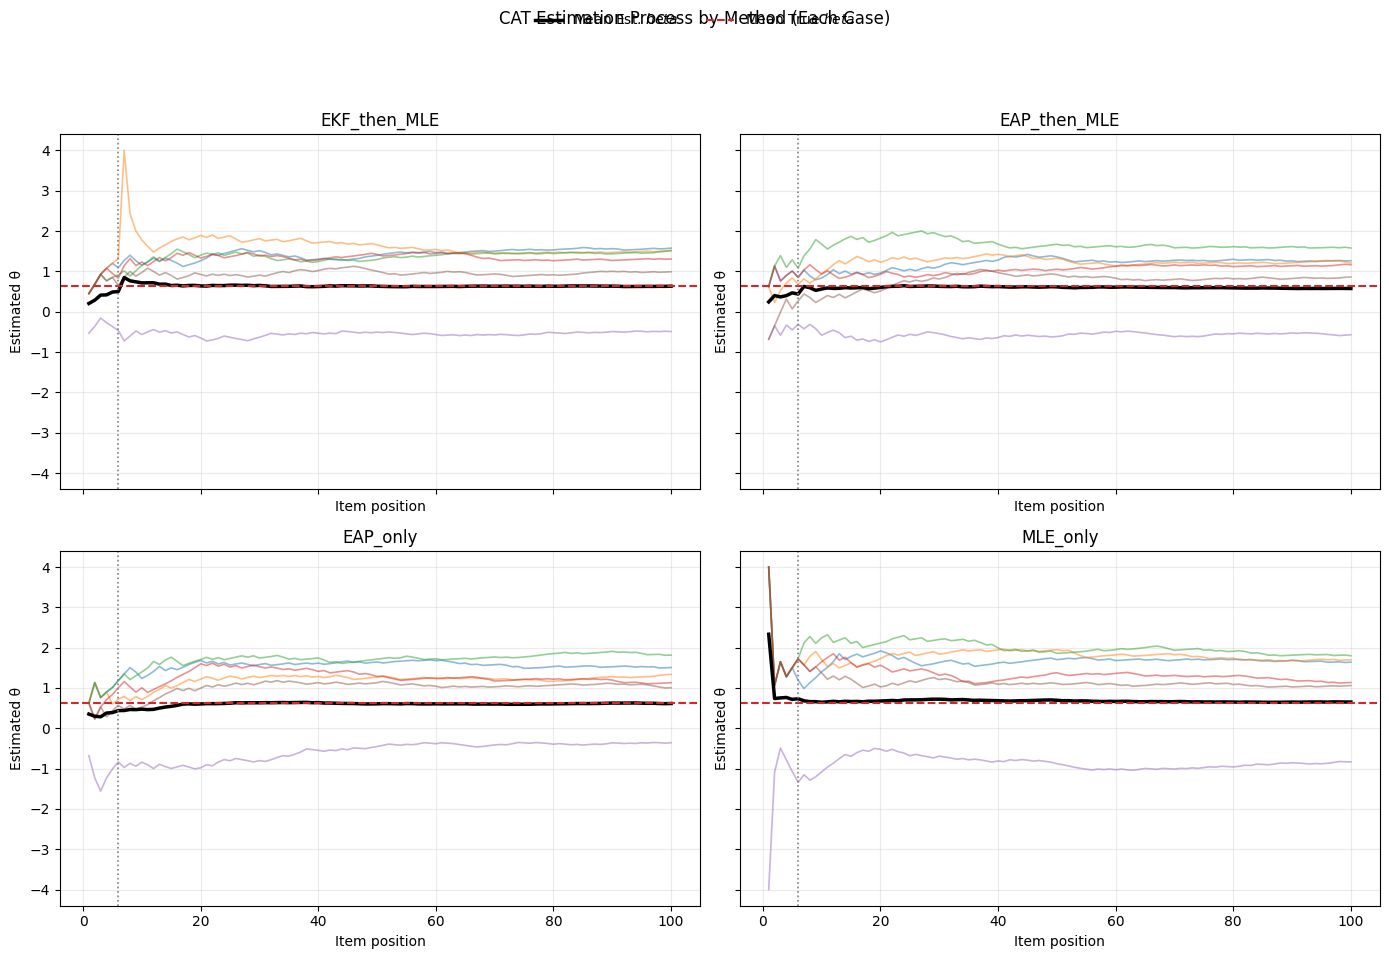

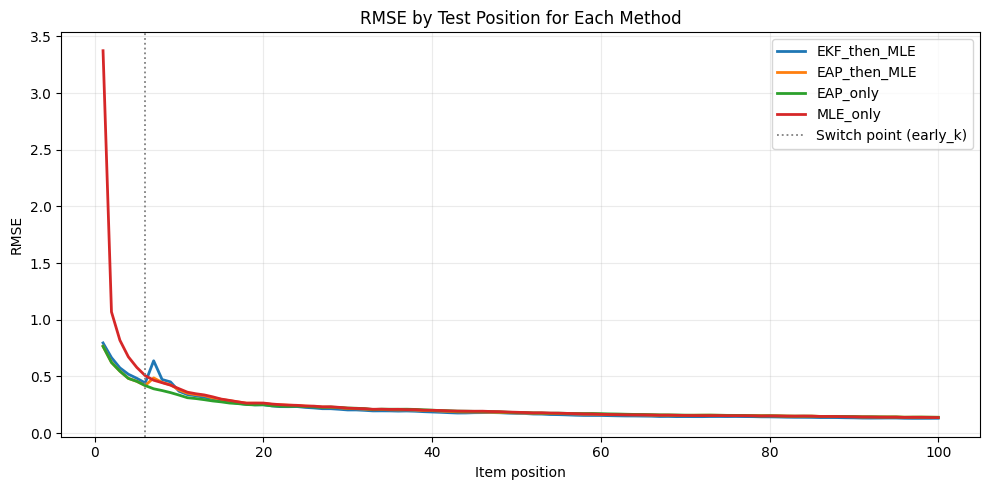

In [15]:
import matplotlib.pyplot as plt

# Ensure summary is available for RMSE curves
if 'summary' not in globals():
    summary = simulate(n_people=300, n_bank=800, test_len=100, early_k=6, seed=123)

methods = ["EKF_then_MLE", "EAP_then_MLE", "EAP_only", "MLE_only"]
seed = 123
n_people_vis = 24
n_show = 6
n_bank = 800
test_len = 100
early_k = 6

# Build one common item bank and true theta sample for fair comparison
rng = np.random.default_rng(seed)
a_bank = np.clip(rng.lognormal(0, 0.35, n_bank), 0.4, 2.5)
b_bank = rng.normal(0, 1, n_bank)
theta_true = rng.normal(0, 1, n_people_vis)

# Simulate theta paths per method
paths = {m: np.zeros((n_people_vis, test_len)) for m in methods}
for m_idx, m in enumerate(methods):
    for i in range(n_people_vis):
        rng_i = np.random.default_rng(seed + 1000 * i + 97 * m_idx)
        paths[m][i] = run_cat_one_person(
            theta_true[i],
            a_bank,
            b_bank,
            test_len=test_len,
            early_k=early_k,
            method=m,
            rng=rng_i,
        )

positions = np.arange(1, test_len + 1)

# Figure 1: Process trajectories for each method (case)
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
for ax, m in zip(axes.ravel(), methods):
    for i in range(n_show):
        ax.plot(positions, paths[m][i], lw=1.2, alpha=0.5)
    ax.plot(positions, paths[m].mean(axis=0), color='black', lw=2.5, label='Mean Est. $\theta$')
    ax.axhline(theta_true.mean(), color='tab:red', ls='--', lw=1.5, label='Mean True $\theta$')
    ax.axvline(early_k, color='gray', ls=':', lw=1.2)
    ax.set_title(m)
    ax.set_xlabel('Item position')
    ax.set_ylabel('Estimated θ')
    ax.grid(alpha=0.25)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
fig.suptitle('CAT Estimation Process by Method (Each Case)', y=1.06)
fig.tight_layout()
plt.show()

# Figure 2: RMSE progression by test position
plt.figure(figsize=(10, 5))
for m in methods:
    plt.plot(positions, summary[m]['rmse_by_position'], lw=2, label=m)

plt.axvline(early_k, color='gray', ls=':', lw=1.3, label='Switch point (early_k)')
plt.xlabel('Item position')
plt.ylabel('RMSE')
plt.title('RMSE by Test Position for Each Method')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# # Robust grid search for optimal switch point (early_k) in EKF_then_MLE
# import numpy as np
# import matplotlib.pyplot as plt

# base_seed = 2026
# n_seeds = 8
# seed_values = [base_seed + 101 * s for s in range(n_seeds)]

# n_people_opt = 500
# n_bank_opt = 800
# test_len_opt = 100
# k_values = np.arange(1, test_len_opt + 1)

# # Store per-seed RMSE curves: shape = (n_seeds, n_k)
# rmse_matrix = np.zeros((n_seeds, len(k_values)), dtype=float)
# best_k_per_seed = np.zeros(n_seeds, dtype=int)

# for s_idx, seed_s in enumerate(seed_values):
#     rng = np.random.default_rng(seed_s)
#     a_bank_opt = np.clip(rng.lognormal(0, 0.35, n_bank_opt), 0.4, 2.5)
#     b_bank_opt = rng.normal(0, 1, n_bank_opt)
#     theta_true_opt = rng.normal(0, 1, n_people_opt)

#     for k_idx, k in enumerate(k_values):
#         final_est = np.zeros(n_people_opt)
#         for i in range(n_people_opt):
#             rng_i = np.random.default_rng(seed_s + 10000 * i)
#             path_i = run_cat_one_person(
#                 theta_true_opt[i],
#                 a_bank_opt,
#                 b_bank_opt,
#                 test_len=test_len_opt,
#                 early_k=int(k),
#                 method="EKF_then_MLE",
#                 rng=rng_i,
#             )
#             final_est[i] = path_i[-1]

#         err = final_est - theta_true_opt
#         rmse_matrix[s_idx, k_idx] = np.sqrt(np.mean(err**2))

#     best_k_per_seed[s_idx] = int(k_values[np.argmin(rmse_matrix[s_idx])])

# # Aggregate robustness statistics
# mean_rmse = rmse_matrix.mean(axis=0)
# std_rmse = rmse_matrix.std(axis=0, ddof=1)
# se_rmse = std_rmse / np.sqrt(n_seeds)
# ci95 = 1.96 * se_rmse

# best_idx = int(np.argmin(mean_rmse))
# best_k = int(k_values[best_idx])
# best_rmse = float(mean_rmse[best_idx])

# # "Stable" choice: smallest k within 1-SE of best mean RMSE
# one_se_cutoff = best_rmse + se_rmse[best_idx]
# stable_candidates = k_values[mean_rmse <= one_se_cutoff]
# stable_k = int(np.min(stable_candidates))

# print(f"Robust optimization across {n_seeds} seeds")
# print(f"Best k by mean RMSE: {best_k} (mean RMSE={best_rmse:.4f})")
# print(f"Stable k (1-SE rule): {stable_k}\n")

# print("Best k per seed:", best_k_per_seed.tolist())
# print()

# rank = np.argsort(mean_rmse)
# print("Top 10 switch points by mean final RMSE (±95% CI):")
# for r in rank[:10]:
#     k_r = int(k_values[r])
#     print(f"  k={k_r:2d} -> {mean_rmse[r]:.4f} ± {ci95[r]:.4f}")

# # Visualization of robust objective
# plt.figure(figsize=(10, 5))
# plt.plot(k_values, mean_rmse, marker='o', lw=2, label='Mean final RMSE')
# plt.fill_between(k_values, mean_rmse - ci95, mean_rmse + ci95, alpha=0.2, label='95% CI')
# plt.axvline(best_k, color='tab:green', ls='--', lw=1.5, label=f'Best k = {best_k}')
# plt.axvline(stable_k, color='tab:purple', ls=':', lw=1.5, label=f'Stable k (1-SE) = {stable_k}')
# plt.xlabel('Switch point (early_k)')
# plt.ylabel('Final RMSE')
# plt.title('Robust Search for EKF→MLE Switch Point')
# plt.grid(alpha=0.25)
# plt.legend()
# plt.tight_layout()
# plt.show()

Fixed early_k = 11
Scenarios run: 320 = 4 seeds × 4 theta dists × 5 lengths × 4 init strategies

Best overall setup by mean RMSE across theta distributions:
  test_len=100, init=random, mean RMSE=0.1591, mean bias=-0.0101
Stable (shorter) setup within ~1-SE envelope:
  test_len=100, init=random, mean RMSE=0.1591, mean bias=-0.0101

Top 10 overall (averaged over theta distributions):
test_len init_strategy mean_rmse mean_bias
     100        random     0.159    -0.010
     100 max_info_at_0     0.159    -0.008
     100   b_nearest_0     0.159    -0.008
     100         max_a     0.160    -0.006
      80 max_info_at_0     0.170    -0.010
      80        random     0.170    -0.013
      80   b_nearest_0     0.171    -0.008
      80         max_a     0.172    -0.008
      60 max_info_at_0     0.184    -0.012
      60   b_nearest_0     0.185    -0.007

Marginal effect: theta distribution (lower RMSE is better)
theta_dist
normal_0_1      0.185201
bimodal         0.191529
normal_0_1.5    0.20

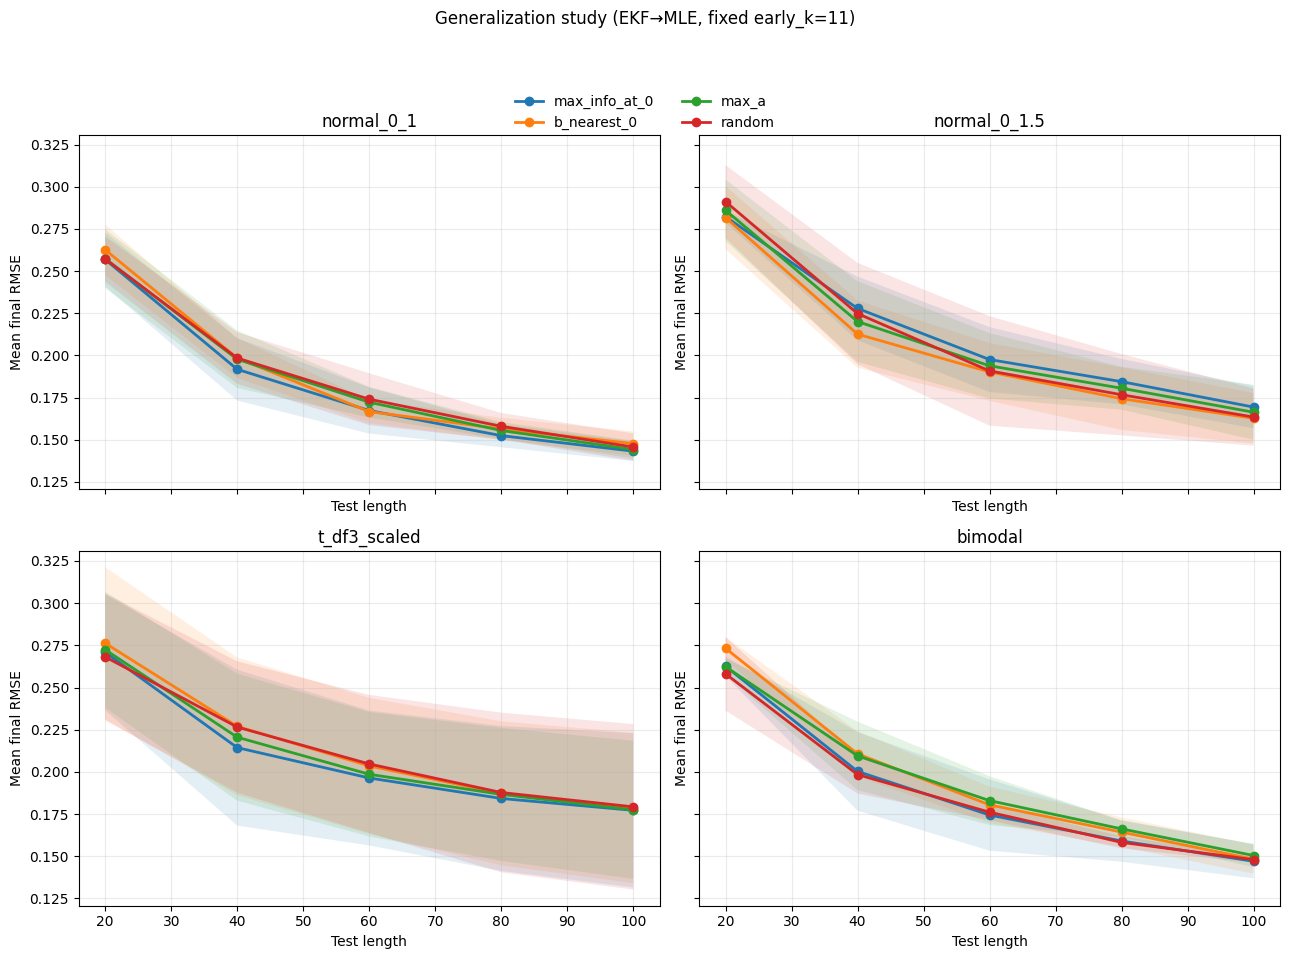

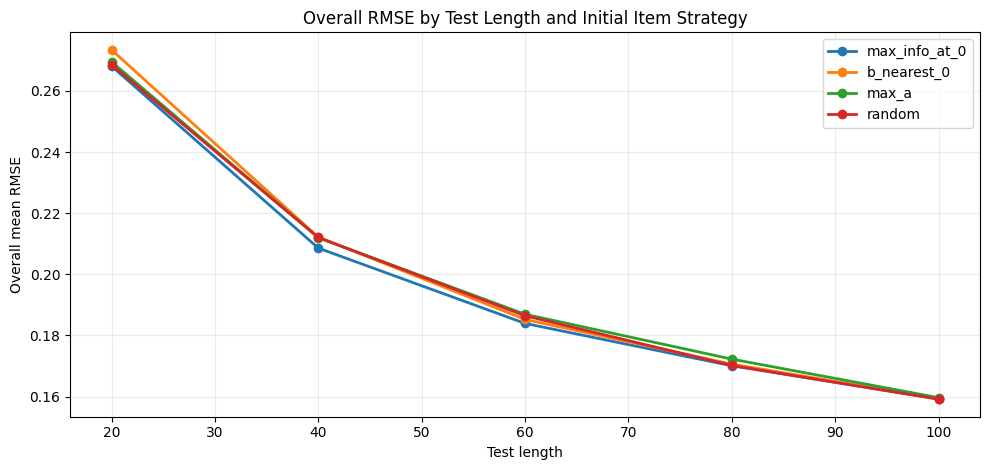

In [17]:
# Comprehensive robustness study for EKF_then_MLE with fixed optimal k=11
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Study settings
# ----------------------------
EARLY_K_FIXED = 11
SEEDS = [1201, 1301, 1409, 1511]
N_PEOPLE = 120
N_BANK = 800

THETA_DISTS = [
    "normal_0_1",
    "normal_0_1.5",
    "t_df3_scaled",
    "bimodal",
]
TEST_LENGTHS = [20, 40, 60, 80, 100]
INIT_STRATEGIES = [
    "max_info_at_0",
    "b_nearest_0",
    "max_a",
    "random",
]

# ----------------------------
# Helpers
# ----------------------------
def sample_theta(dist_name, n_people, rng):
    if dist_name == "normal_0_1":
        return rng.normal(0, 1, n_people)
    if dist_name == "normal_0_1.5":
        return rng.normal(0, 1.5, n_people)
    if dist_name == "t_df3_scaled":
        # Heavy-tailed with roughly unit variance
        return rng.standard_t(df=3, size=n_people) / np.sqrt(3)
    if dist_name == "bimodal":
        comp = rng.integers(0, 2, n_people)
        means = np.where(comp == 0, -1.0, 1.0)
        return rng.normal(means, 0.7)
    raise ValueError("Unknown theta distribution")


def choose_first_item(a_bank, b_bank, theta_hat, strategy, rng, precomputed):
    if strategy == "max_info_at_0":
        return precomputed["max_info_at_0"]
    if strategy == "b_nearest_0":
        return precomputed["b_nearest_0"]
    if strategy == "max_a":
        return precomputed["max_a"]
    if strategy == "random":
        return int(rng.integers(0, len(a_bank)))
    raise ValueError("Unknown init strategy")


def run_cat_one_person_custom_init(
    theta_true,
    a_bank,
    b_bank,
    test_len,
    early_k,
    init_strategy,
    rng,
    precomputed
):
    n_items = len(a_bank)
    remaining = np.ones(n_items, dtype=bool)

    theta_hat = 0.0
    P = 1.0

    u_used, a_used, b_used = [], [], []
    theta_path = np.zeros(test_len)

    for t in range(test_len):
        if t == 0:
            j = choose_first_item(a_bank, b_bank, theta_hat, init_strategy, rng, precomputed)
            if not remaining[j]:
                # Safety fallback
                j = int(np.where(remaining)[0][0])
        else:
            infos = np.full(n_items, -np.inf)
            idxs = np.where(remaining)[0]
            infos[idxs] = fisher_info_2pl(a_bank[idxs], b_bank[idxs], theta_hat)
            j = int(np.argmax(infos))

        remaining[j] = False

        u = simulate_response(a_bank[j], b_bank[j], theta_true, rng)
        u_used.append(u)
        a_used.append(a_bank[j])
        b_used.append(b_bank[j])

        u_arr = np.array(u_used)
        a_arr = np.array(a_used)
        b_arr = np.array(b_used)

        if t < early_k:
            theta_hat, P = ekf_update(theta_hat, P, u, a_bank[j], b_bank[j])
        else:
            theta_hat = mle_estimate(u_arr, a_arr, b_arr, theta_init=theta_hat)

        theta_path[t] = theta_hat

    return theta_path


# ----------------------------
# Factorial simulation
# ----------------------------
rows = []
for seed in SEEDS:
    rng_bank = np.random.default_rng(seed)
    a_bank = np.clip(rng_bank.lognormal(0, 0.35, N_BANK), 0.4, 2.5)
    b_bank = rng_bank.normal(0, 1, N_BANK)

    precomputed = {
        "max_info_at_0": int(np.argmax(fisher_info_2pl(a_bank, b_bank, 0.0))),
        "b_nearest_0": int(np.argmin(np.abs(b_bank))),
        "max_a": int(np.argmax(a_bank)),
    }

    for theta_dist in THETA_DISTS:
        rng_theta = np.random.default_rng(seed + 555)
        theta_true = sample_theta(theta_dist, N_PEOPLE, rng_theta)

        for test_len in TEST_LENGTHS:
            for init_strategy in INIT_STRATEGIES:
                final_est = np.zeros(N_PEOPLE)

                for person_i in range(N_PEOPLE):
                    rng_i = np.random.default_rng(seed * 100000 + 1000 * person_i + 17)
                    path = run_cat_one_person_custom_init(
                        theta_true=theta_true[person_i],
                        a_bank=a_bank,
                        b_bank=b_bank,
                        test_len=test_len,
                        early_k=EARLY_K_FIXED,
                        init_strategy=init_strategy,
                        rng=rng_i,
                        precomputed=precomputed,
                    )
                    final_est[person_i] = path[-1]

                err = final_est - theta_true
                rows.append({
                    "seed": seed,
                    "theta_dist": theta_dist,
                    "test_len": test_len,
                    "init_strategy": init_strategy,
                    "rmse": float(np.sqrt(np.mean(err**2))),
                    "bias": float(np.mean(err)),
                })

res = pd.DataFrame(rows)

# ----------------------------
# Aggregation for generalization
# ----------------------------
agg = (
    res.groupby(["theta_dist", "test_len", "init_strategy"], as_index=False)
    .agg(
        mean_rmse=("rmse", "mean"),
        sd_rmse=("rmse", "std"),
        mean_bias=("bias", "mean"),
        sd_bias=("bias", "std"),
        n=("rmse", "count"),
    )
)
agg["se_rmse"] = agg["sd_rmse"] / np.sqrt(agg["n"])
agg["ci95_rmse"] = 1.96 * agg["se_rmse"]

overall = (
    agg.groupby(["test_len", "init_strategy"], as_index=False)
    .agg(
        mean_rmse=("mean_rmse", "mean"),
        mean_bias=("mean_bias", "mean"),
    )
    .sort_values("mean_rmse")
)

best_row = overall.iloc[0]
one_se_cut = best_row["mean_rmse"] + (agg["se_rmse"].mean())
stable_pool = overall[overall["mean_rmse"] <= one_se_cut]
stable_row = stable_pool.sort_values(["test_len", "mean_rmse"]).iloc[0]

print(f"Fixed early_k = {EARLY_K_FIXED}")
print(f"Scenarios run: {len(res)} = {len(SEEDS)} seeds × {len(THETA_DISTS)} theta dists × {len(TEST_LENGTHS)} lengths × {len(INIT_STRATEGIES)} init strategies")
print()

print("Best overall setup by mean RMSE across theta distributions:")
print(f"  test_len={int(best_row['test_len'])}, init={best_row['init_strategy']}, mean RMSE={best_row['mean_rmse']:.4f}, mean bias={best_row['mean_bias']:.4f}")
print("Stable (shorter) setup within ~1-SE envelope:")
print(f"  test_len={int(stable_row['test_len'])}, init={stable_row['init_strategy']}, mean RMSE={stable_row['mean_rmse']:.4f}, mean bias={stable_row['mean_bias']:.4f}")
print()

print("Top 10 overall (averaged over theta distributions):")
print(overall.head(10).to_string(index=False, formatters={'mean_rmse': '{:.3f}'.format, 'mean_bias': '{:.3f}'.format, 'test_len': '{:.0f}'.format}))

# Factor summaries
print("\nMarginal effect: theta distribution (lower RMSE is better)")
print(res.groupby("theta_dist")["rmse"].mean().sort_values().to_string())
print("\nMarginal effect: test length")
print(res.groupby("test_len")["rmse"].mean().sort_values().to_string())
print("\nMarginal effect: initial item selection")
print(res.groupby("init_strategy")["rmse"].mean().sort_values().to_string())

# ----------------------------
# Plots
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
for ax, dist in zip(axes.ravel(), THETA_DISTS):
    sub = agg[agg["theta_dist"] == dist].copy()
    for init in INIT_STRATEGIES:
        s = sub[sub["init_strategy"] == init].sort_values("test_len")
        ax.plot(s["test_len"], s["mean_rmse"], marker='o', lw=2, label=init)
        ax.fill_between(
            s["test_len"],
            s["mean_rmse"] - s["ci95_rmse"],
            s["mean_rmse"] + s["ci95_rmse"],
            alpha=0.12,
        )
    ax.set_title(dist)
    ax.set_xlabel("Test length")
    ax.set_ylabel("Mean final RMSE")
    ax.grid(alpha=0.25)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=2, frameon=False)
fig.suptitle("Generalization study (EKF→MLE, fixed early_k=11)", y=1.06)
fig.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.8))
for init in INIT_STRATEGIES:
    s = overall[overall["init_strategy"] == init].sort_values("test_len")
    plt.plot(s["test_len"], s["mean_rmse"], marker='o', lw=2, label=init)
plt.xlabel("Test length")
plt.ylabel("Overall mean RMSE")
plt.title("Overall RMSE by Test Length and Initial Item Strategy")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()